**PatchTST** - <small>Enhancement to experiment v4_0</small>

# Code

## Configuration & General

In [1]:
!pip install torchmetrics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 27.2 MB/s eta 0:00:00


In [2]:
import os

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import wandb
from google.colab import drive
from joblib import dump, load
from sklearn import set_config
from torch.utils.data import DataLoader, Dataset
from torchmetrics.regression import MeanAbsoluteError, MeanSquaredError, R2Score

set_config(transform_output="pandas")

# --- CONFIGURATION & GLOBALS ---
drive.mount('/content/drive')
wandb.login()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.style.use("ggplot")


BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/GP Datasets/"
MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

MAIN_CSV_FILE = "25_countries_main.csv"
MAIN_CSV_PATH = os.path.join(BASE_DIR, MAIN_CSV_FILE)

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: WARNING Invalid choice
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: mohamedhussien (sehetna) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
targets = ['respiratory_disease_rate', 'cardio_mortality_rate', 'vector_disease_risk_score', 'waterborne_disease_incidents', 'heat_related_admissions']

In [4]:
countries_ids = joblib.load(os.path.join(MODELS_DIR, "country_to_idx.joblib"))
ids_countries = joblib.load(os.path.join(MODELS_DIR, "idx_to_country.joblib"))

In [5]:
data_df = pd.read_csv(MAIN_CSV_PATH, parse_dates=["date"])

data_df['country_id'] = data_df['country_code'].map(countries_ids)

data_df.shape

(14100, 33)

## Preprocessing & Feature Engineering

### Helpers

In [6]:
# @title
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [7]:
# @title
class FeatureEngineerMixin(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise ValueError("X must be a pandas DataFrame")

        X_copy = X.copy()

        X_copy['date'] = pd.to_datetime(X_copy['date'])

        X_copy['day_of_week'] = X_copy['date'].dt.dayofweek
        X_copy['quarter'] = X_copy['date'].dt.quarter

        # Add Cyclic Encoding Transformations for dates and seasons.
        X_copy['month_sin'] = np.sin(2 * np.pi * X_copy['month'] / 12)
        X_copy['month_cos'] = np.cos(2 * np.pi * X_copy['month'] / 12)
        X_copy['week_sin'] = np.sin(2 * np.pi * X_copy['week'] / 52)
        X_copy['week_cos'] = np.cos(2 * np.pi * X_copy['week'] / 52)

        # A. Temporal Lags (The "Incubation Period")
        # We look back 1 week for pollution and temprature because diseases aren't instant.
        X_copy['pm25_ugm3_lag_1w'] = X_copy.groupby('country_code')['pm25_ugm3'].shift(1)
        X_copy['pm25_ugm3_lag_2w'] = X_copy.groupby('country_code')['pm25_ugm3'].shift(2)
        X_copy['pm25_ugm3_lag_4w'] = X_copy.groupby('country_code')['pm25_ugm3'].shift(4)

        X_copy['temp_lag_1w'] = X_copy.groupby('country_code')['temperature_celsius'].shift(1)
        X_copy['temp_lag_2w'] = X_copy.groupby('country_code')['temperature_celsius'].shift(2)

        # B. Rolling Averages (The "Chronic Exposure")
        # B1. We calculate the average temperature of the last 4 weeks.
        X_copy['temp_2w_avg'] = (
            X_copy.groupby('country_code')['temperature_celsius'].transform(lambda x: x.rolling(window=2, min_periods=1).mean())
        )

        # B2. Rolling standard deviation (volatility)
        X_copy['temp_2w_volatility'] = (
            X_copy.groupby('country_code')['temperature_celsius'].transform(lambda x: x.rolling(window=2, min_periods=1).std())
        )

        X_copy['temp_4w_volatility'] = (
            X_copy.groupby('country_code')['temperature_celsius'].transform(lambda x: x.rolling(window=4, min_periods=1).std())
        )

        # C. Mathematical Transformations (Non-Linearity)
        # Temperature usually has a U-shaped effect on health (bad if too hot OR too cold)
        X_copy['temp_squared'] = X_copy['temperature_celsius'] ** 2

        # Log-Transform Target Variables
        # We do NOT scale this later.
        # X_copy['food_security_index_log'] = np.log1p(X_copy['food_security_index'])


        # D. Scientific Logic: The human body adapts to gradual change.
        # Sudden spikes (Thermal Shock) cause heart attacks and asthma attacks.
        # D1. We calculate: (Current Week Value) - (Last Week Value)
        X_copy['temp_change_rate'] = X_copy.groupby('country_code')['temperature_celsius'].diff()
        X_copy['pm25_change_rate'] = X_copy.groupby('country_code')['pm25_ugm3'].diff()
        X_copy['precip_change_rate'] = X_copy.groupby('country_code')['precipitation_mm'].diff()

        # E. Calculate Spatial Lag for Respiratory Disease
        # We take the average disease rate of the 5 neighbors (excluding the country itself)
        coords = X_copy[['latitude' , 'longitude']].values

        nbrs = NearestNeighbors(n_neighbors=5 , algorithm='ball_tree').fit(coords)
        distances , indices = nbrs.kneighbors(coords)

        neighbor_idx = indices[: , 1:] # Drop the first one (itself)

        X_copy['spatial_lag_pm25'] = X_copy['pm25_ugm3'].values[neighbor_idx].mean(axis=1)
        X_copy['spatial_lag_temp'] = X_copy['temperature_celsius'].values[neighbor_idx].mean(axis=1)
        X_copy['spatial_lag_temp_anomaly'] = X_copy['temp_anomaly_celsius'].values[neighbor_idx].mean(axis=1)

        # F. The "Photochemical Smog" Effect
        # Scientific Logic: High heat catalyzes chemical reactions in pollutants (like Ozone/PM2.5), making them more toxic to the lungs.
        X_copy['pm25_temp_interaction'] = X_copy['pm25_ugm3'] * X_copy['temperature_celsius']
        X_copy['temp_precip_interaction'] = X_copy['temperature_celsius'] * X_copy['precipitation_mm']
        X_copy['pm25_precip_interaction'] = X_copy['pm25_ugm3'] * X_copy['precipitation_mm']

        # G. Hemisphere Indicators
        X_copy['is_northern'] = (X_copy['latitude'] > 0).astype(int)
        X_copy['is_tropical'] = (X_copy['latitude'].abs() < 23.5).astype(int)
        X_copy['distance_to_equator'] = X_copy['latitude'].abs()


        # I. The "Vulnerability" Effect
        # Scientific Logic: High pollution is manageable if Healthcare Access is high.
        # It becomes fatal if Healthcare is low.
        # We add a small epsilon (1e-6) to avoid division by zero.

        X_copy['pollution_vulnerability'] = X_copy['pm25_ugm3'] / (X_copy['healthcare_access_index'] + 1e-6)

        X_copy = X_copy.drop(columns=['month', 'week'])
        X_copy.fillna(X_copy.mean(numeric_only=True), inplace=True)

        self.feature_names_ = X_copy.columns.tolist()

        return X_copy

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_
        return self.feature_names_

In [8]:
# @title
class CountryIQRCapper(BaseEstimator, TransformerMixin):
    def __init__(self, country_col='country_id', multiplier=1.5):
        self.country_col = country_col
        self.multiplier = multiplier

    def fit(self, X, y=None):
        self.feature_names_ = X.columns.tolist()
        self.bounds_ = {}

        for country in X[self.country_col].unique():
            mask = X[self.country_col] == country
            country_data = X.loc[mask, self.feature_names_]

            self.bounds_[country] = {}

            for col in self.feature_names_:
                if col == self.country_col:
                    continue

                series = country_data[col].dropna()

                if len(series) < 10:
                    self.bounds_[country][col] = (series.min(), series.max())
                    continue

                Q1 = series.quantile(0.25)
                Q3 = series.quantile(0.75)
                IQR = Q3 - Q1

                if IQR == 0:
                    self.bounds_[country][col] = (series.min(), series.max())
                    continue

                lower = Q1 - self.multiplier * IQR
                upper = Q3 + self.multiplier * IQR
                self.bounds_[country][col] = (lower, upper)

        return self

    def transform(self, X):
        if not hasattr(self, 'bounds_'):
            raise ValueError("Capper has not been fitted yet. Call fit() first.")

        _X = X.copy()

        for country in _X[self.country_col].unique():
            mask = _X[self.country_col] == country

            if country not in self.bounds_:
                continue

            for col in self.feature_names_:
                if col == self.country_col:
                    continue

                lower, upper = self.bounds_[country][col]
                _X.loc[mask, col] = _X.loc[mask, col].clip(lower=lower, upper=upper)

        return _X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_
        return input_features




In [9]:
# @title
class SelectiveStandardScaler(BaseEstimator, TransformerMixin):
    def __init__(self, exclude_cols=None, drop_excluded=False):
        self.exclude_cols = exclude_cols or []
        self.drop_excluded = drop_excluded

    def fit(self, X, y=None):
        X = X.copy()

        self.scale_cols_ = [c for c in X.columns if c not in self.exclude_cols]

        self.scaler_ = StandardScaler()
        self.scaler_.fit(X[self.scale_cols_])

        self.feature_names_in_ = X.columns.tolist()
        self.feature_names_out_ = self.scale_cols_ if self.drop_excluded else self.feature_names_in_

        return self

    def transform(self, X):
        X_copy = X.copy()

        X_copy[self.scale_cols_] = X_copy[self.scale_cols_].astype("float64")
        X_copy.loc[:, self.scale_cols_] = self.scaler_.transform(X_copy[self.scale_cols_])

        if self.drop_excluded:
            X_copy = X_copy[self.scale_cols_]

        return X_copy

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_out_)

### Pipeline

In [10]:
# @title
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Categorical features
categorical_ordinal = ['income_level']
categorical_onehot = ['region']

# Core numeric features (will be used to create engineered features)
core_numeric_features = [
    'country_id',
    'temperature_celsius', 'temp_anomaly_celsius',
    'pm25_ugm3', 'precipitation_mm',
    'food_security_index', 'population_millions',
    'air_quality_index', 'aqi_pm',
    'gdp_per_capita_usd', 'mental_health_index',
    'uhs_service_coverage_index',
]

# Engineered features (created by FeatureEngineerMixin)
engineered_features = [
    # PM2.5 lags and changes
    'pm25_ugm3_lag_1w', 'pm25_ugm3_lag_2w', 'pm25_ugm3_lag_4w',
    'pm25_change_rate',
    # Temperature lags and volatility
    'temp_lag_1w', 'temp_lag_2w',
    'temp_2w_volatility', 'temp_4w_volatility', 'temp_2w_avg',
    'temp_squared', 'temp_change_rate',
    # Precipitation
    'precip_change_rate',
    # Interactions
    'pm25_temp_interaction', 'pm25_precip_interaction',
    'temp_precip_interaction', 'pollution_vulnerability'
]

# Geographic/spatial features (likely from FeatureEngineerMixin)
spatial_features = [
    'latitude', 'longitude',
    'spatial_lag_pm25', 'spatial_lag_temp', 'spatial_lag_temp_anomaly',
    'is_northern', 'is_tropical', 'distance_to_equator'
]

# Environmental event indicators
event_features = [
    'heat_wave_days', 'drought_indicator',
    'flood_indicator', 'extreme_weather_events'
]

# Temporal features (from FeatureEngineerMixin)
temporal_features = [
    'day_of_week', 'quarter',
    'month_sin', 'month_cos', 'week_sin', 'week_cos'
]

# All numeric features that should be preprocessed
all_numeric_features = (
    core_numeric_features +
    engineered_features +
    spatial_features +
    event_features +
    temporal_features
)

numeric_pipeline = Pipeline([
    ('capped', CountryIQRCapper()),
    # ('scaled', SelectiveStandardScaler(exclude_cols=['country_id'], drop_excluded=True)),
    ('knn_imputer', KNNImputer(n_neighbors=5)),
])

numeric_preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal_categorical', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_ordinal),
        ('onehot_categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_onehot),
        ('preprocessed', numeric_pipeline, all_numeric_features),
    ],
    verbose_feature_names_out=False,
    remainder='passthrough'
)

pipeline = Pipeline([
    ('date_feature_engineer', FeatureEngineerMixin()),
    ('numeric_preprocessing', numeric_preprocessor),
])

target_scaler = StandardScaler()

pipeline

Pipeline(steps=[('date_feature_engineer', FeatureEngineerMixin()),
                ('numeric_preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal_categorical',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['income_level']),
                                                 ('onehot_categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['region']),
                                                 ('...
                                                   'pm25_ugm3_lag_2w',
                                                   'pm25_ugm3_lag_4w',
                                                   'pm25_change_rate',
                                                   'temp_lag_1w', 'temp_lag_2w',
                                                   'temp_2w_volatility',
                                                   'temp_4w_volatility',
                                                   'temp_2w_avg',
                                                   'temp_squared',
                                                   'temp_change_rate',
                                                   'precip_change_rate',
                                                   'pm25_temp_interaction',
                                                   'pm25_precip_interaction',
                                                   'temp_precip_interaction',
                                                   'pollution_vulnerability',
                                                   'latitude', 'longitude', ...])],
                                   verbose_feature_names_out=False))])

## Checkpoint Saver

In [11]:
import copy
import glob
import pickle


class CheckpointSaver:
    def __init__(self, dirpath="./checkpoints", decreasing=True, save_model=True):
        self.dirpath = dirpath
        os.makedirs(dirpath, exist_ok=True)
        self.decreasing = decreasing
        self.save_model = save_model

        # Track the best metric
        self.best_metric = float('inf') if decreasing else float('-inf')

        # We store the best checkpoint in RAM (CPU).
        self.best_checkpoint_payload = None
        self.best_epoch = -1
        self.best_fold = -1
        self.id = None

    def update(self, model, fold, epoch, metric, id):
        """Checks if current model is best. If yes, caches it to RAM."""

        is_best = (metric < self.best_metric) if self.decreasing else (metric > self.best_metric)

        if not is_best:
            return False

        self.best_metric = metric
        self.best_epoch = epoch
        self.best_fold = fold
        self.id = id

        self.best_checkpoint_payload = {
            "epoch": epoch,
            "metric": metric,
            "model_state_dict": {k: v.cpu().clone() for k, v in model.state_dict().items()}
        }

        print(f"-> New Best Model found at Epoch {epoch} | Metric={metric:.4f}")
        return True

    @staticmethod
    def load_artifact_model(run_id, model_instance, project="sehetna/sehetna-main"):
        api = wandb.Api()
        artifact_path = f"{project}/{run_id}"

        try:
            artifact = api.artifact(artifact_path)
        except Exception as e:
            print(f"Error: Could not find artifact at {artifact_path}: {e}")
            return None

        print("-> Downloading artifact...")
        artifact_dir = artifact.download()

        pkl_files = glob.glob(os.path.join(artifact_dir, "*.pkl"))
        if not pkl_files:
            print("Error: No .pkl file found in the artifact.")
            return None

        model_pkl = pkl_files[0]
        print(f"-> Found checkpoint: {os.path.basename(model_pkl)}")

        with open(model_pkl, "rb") as f:
            checkpoint = pickle.load(f)

        state_dict = checkpoint.get("model_state_dict", checkpoint)

        model_instance.load_state_dict(state_dict)
        print("-> Weights successfully loaded into model.")

        return model_instance

    def __call__(self):
        """Call this ONCE at the very end of training."""
        if not self.save_model or self.best_checkpoint_payload is None:
            print("No model to save (or save_model=False).")
            return

        name = f"{self.id}-fold-{self.best_fold}-best-epoch-{self.best_epoch}.pkl"
        best_pkl = os.path.join(self.dirpath, name)

        description = f"Best Model: Fold {self.best_fold} | Epoch {self.best_epoch} | Metric={self.best_metric:.4f}"
        print(f"-> Saving to Disk: {name} ...")

        # Save to Disk
        with open(best_pkl, "wb") as f:
            pickle.dump(self.best_checkpoint_payload, f)

        # Upload to WandB
        if wandb.run is not None:
            print("-> Uploading to WandB...")
            artifact = wandb.Artifact(name=f"model-{self.id}", type="model", description=description)
            artifact.add_file(best_pkl)
            wandb.log_artifact(artifact)
            print("-> Upload Complete.")

## Feature Selection

In [12]:
# @title
features = [
    # ==================================================
    # 'temperature_celsius','temp_lag_1w','temp_lag_2w','temp_2w_avg','temp_change_rate','pm25_change_rate','spatial_lag_temp','temp_anomaly_celsius','precipitation_mm','air_quality_index','aqi_pm','pm25_ugm3','pm25_ugm3_lag_1w','pm25_ugm3_lag_2w','spatial_lag_pm25','pollution_vulnerability','temp_precip_interaction','pm25_temp_interaction','pm25_precip_interaction','gdp_per_capita_usd','healthcare_access_index','week_cos','week_sin',
    # ==================================================

    'temp_squared', 'pm25_ugm3', 'heat_wave_days', 'month_sin',
    'temp_precip_interaction', 'aqi_pm', 'temp_anomaly_celsius',
    'pollution_vulnerability', 'flood_indicator', 'healthcare_access_index',
    'distance_to_equator', 'pm25_change_rate', 'pm25_ugm3_lag_1w', 'month_cos',
    'temp_change_rate', 'temperature_celsius', 'gdp_per_capita_usd',
    'quarter', 'spatial_lag_pm25', 'is_northern',
    'is_tropical', 'spatial_lag_temp', 'food_security_index',
]


## Datasets & Model

### Dataset

In [13]:
class ClimateHealthDataset(Dataset):
    def __init__(self, df, seq_len=12, horizon_len=6):
        self.samples = []

        df = df.copy()
        df["country_id"] = df["country_name"].map(countries_ids)

        for _, country_df in df.groupby("country_id"): # Each country_df.shape[0] = ~522
            country_df = country_df.sort_values("date").reset_index(drop=True)

            y = data_df[targets].values.astype("float32")

            max_t = len(data_df) - horizon_len # 522 - 6 = 516

            for t in range(seq_len, max_t):
                self.samples.append({"y_past":   y[t - seq_len : t], "y_future": y[t : t + horizon_len]})

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        """
        ## Shapes returned
        - y_past   : [seq_len, num_targets]
        - y_future : [horizon_len, num_targets]

        :param idx: Index of the current batch
        """
        s = self.samples[idx]
        return torch.from_numpy(s["y_past"]), torch.from_numpy(s["y_future"])

### Model

In [14]:
from transformers import PatchTSTConfig, PatchTSTForPrediction


class PatchTST(nn.Module):
    def __init__(self, config, num_targets):
        super().__init__()

        model_config = PatchTSTConfig(
            num_input_channels=num_targets,
            context_length=config.seq_len,
            prediction_length=config.prediction_len,

            d_model=config.d_model,
            n_heads=config.n_heads,
            num_hidden_layers=config.num_layers,

            patch_length=config.patch_len,
            stride=config.patch_stride,
            dropout=config.dropout,

            loss="mse"
        )

        self.patchtst_model = PatchTSTForPrediction(model_config)

    def forward(self, y_past, y_future):
        outputs = self.patchtst_model(past_values=y_past, future_values=y_future)

        return outputs


## Data Preparation Helpers

### TimeSeries Splitting

In [15]:
# @title
def ts_fold_split(df, min_train_years=9, test_years=2, year_col="year"):
    years = sorted(df[year_col].unique().tolist())

    min_years_needed = min_train_years + test_years
    assert len(years) >= min_years_needed, (
        f"Not enough unique years ({len(years)}) for "
        f"min_train_years={min_train_years}, "
        f"test_years={test_years}"
    )

    max_folds = len(years) - min_years_needed + 1

    folds = []

    for i in range(max_folds):
        train_end = min_train_years + i
        test_end = train_end + test_years

        train_years = years[:train_end]
        test_years_ = years[train_end:test_end]

        train_idx = df[df[year_col].isin(train_years)].index.tolist()
        test_idx  = df[df[year_col].isin(test_years_)].index.tolist()

        if not train_idx or not test_idx:
            continue

        folds.append({
            "train_idx": train_idx,
            "test_idx": test_idx,

            "train_years": train_years,
            "test_years": test_years_,
        })

    return folds

### Build Folds

In [16]:
def build_folds(df, seq_len=12, horizon_len=6, min_train_years=5, test_years=1):
    folds = []
    folds_info = ts_fold_split(df, min_train_years, test_years)

    for fold in folds_info:
        train_df = df.loc[fold["train_idx"]]
        test_df  = df.loc[fold["test_idx"]]

        train_df = pipeline.fit_transform(train_df)
        test_df  = pipeline.transform(test_df)

        # Scale targets on the original raw target columns
        train_df[targets] = target_scaler.fit_transform(train_df[targets])
        test_df[targets] = target_scaler.transform(test_df[targets])

        folds.append({
            # Loaders
            "train_loader": DataLoader(ClimateHealthDataset(train_df, seq_len, horizon_len), batch_size=128, shuffle=True),
            "test_loader":  DataLoader(ClimateHealthDataset(test_df, seq_len, horizon_len), batch_size=256),

            # Metadata
            "train_years": fold["train_years"],
            "test_years":  fold["test_years"],
        })

    return folds

## Training & Validation Loops

In [17]:
from torch.amp import GradScaler, autocast


def train_one_epoch(model, loader, optimizer, scheduler=None):
    model.train()
    epoch_losses = []

    scaler = GradScaler()

    for y_past, y_future in loader:
        y_past, y_future = y_past.to(device), y_future.to(device)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device.type):
            outputs = model(y_past, y_future)
            loss = outputs.loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        if scheduler is not None:
            scheduler.step()

        epoch_losses.append(loss.item())

    return float(np.mean(epoch_losses))


In [18]:
@torch.no_grad()
def validate_one_epoch(model, loader):
    model.eval()

    mse_metric = MeanSquaredError().to(device)
    mae_metric = MeanAbsoluteError().to(device)
    r2_metric  = R2Score().to(device)

    total_loss = 0.0
    total_samples = 0

    for y_past, y_future in loader:
        y_past, y_future = y_past.to(device), y_future.to(device)

        with autocast(device.type):
            outputs = model(y_past, y_future)
            loss, preds = outputs.loss, outputs.prediction_outputs

        batch_size = y_future.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        preds_flat = preds.contiguous().view(-1, preds.size(-1))
        target_flat = y_future.contiguous().view(-1, y_future.size(-1))

        mse_metric.update(preds_flat, target_flat)
        mae_metric.update(preds_flat, target_flat)
        r2_metric.update(preds_flat, target_flat)

    mse = mse_metric.compute().item()
    mae = mae_metric.compute().item()
    rmse = mse ** 0.5
    r2 = r2_metric.compute().item()
    avg_loss = total_loss / total_samples

    return avg_loss, mae, rmse, r2

In [19]:
def train(model, fold, train_loader, test_loader, optimizer, id, e, scheduler=None, save=False):
    Saver = CheckpointSaver(save_model=save)
    for epoch in range(1, e + 1):
        t_loss = train_one_epoch(model, train_loader, optimizer, scheduler)
        v_loss, mae, rmse, r2 = validate_one_epoch(model, test_loader)
        current_lr = optimizer.param_groups[0]['lr']

        wandb.log({"train/loss": t_loss, "val/loss_mse": v_loss, "val/rmse": rmse, "val/mae": mae, "val/r2": r2, "lr": current_lr, "epoch": epoch, "fold": fold})
        print(f"Fold {fold} | Epoch {epoch} => Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | Val RMSE: {rmse:.4f} | Val MAE: {mae:.4f} | Val R2: {r2:.4f}")

        Saver.update(model, fold, epoch, mae, id)

    Saver()

## Start Training

In [20]:
train_test_split = ts_fold_split(data_df, min_train_years=9, test_years=2)[0]

_train_df = data_df.loc[train_test_split["train_idx"]]

In [21]:
# Testing...
folds = build_folds(_train_df, seq_len=12, horizon_len=6, min_train_years=4, test_years=3)
print(f"Total folds: {len(folds)}")

for f in folds:
    print(f"Train: {f['train_years']} | Val: {f['test_years']}")

Total folds: 3
Train: [2015, 2016, 2017, 2018] | Val: [2019, 2020, 2021]
Train: [2015, 2016, 2017, 2018, 2019] | Val: [2020, 2021, 2022]
Train: [2015, 2016, 2017, 2018, 2019, 2020] | Val: [2021, 2022, 2023]


In [22]:
from torch.optim.lr_scheduler import OneCycleLR

def start(config=None):
    with wandb.init(config=config) as run:
        from sklearn import set_config
        set_config(transform_output="pandas")

        config = wandb.config

        folds = build_folds(_train_df, config.seq_len, config.prediction_len, config.min_train_years, config.test_years)

        print(f"Total folds: {len(folds)}")

        for f in folds:
            print(f"Train: {f['train_years']} | Val: {f['test_years']}")

        for i, fold in enumerate(folds, start=1):
            model = PatchTST(config, len(targets)).to(device)

            optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
            scheduler = None

            if config.scheduler:
                scheduler = OneCycleLR(optimizer, max_lr=config.lr * 5, steps_per_epoch=len(fold["train_loader"]), epochs=config.e)

            print(f"\nFold {i} | Train: {fold['train_years']} | Test: {fold['test_years']}")
            train(model, i, fold["train_loader"], fold["test_loader"], optimizer, run.id, config.e, scheduler)

## Sweep Configuration

In [23]:
# ------- Versioning -------
# v0 Major: changing and introducing new layers, defining new splitting technique, or adjusting features.
# v0.0 minor: adding/removing new sweep configuration parameter keys.
# v0.0.0 patch: updating values of sweep configuration parameters.

sweep_configuration = {
    "name": "climate-health-patchtst-v7.0.1",
    "method": "bayes",
    "metric": { "name": "val/mae", "goal": "minimize" },
    "parameters": {
        # MODEL ARCHITECTURE
        "d_model": { "values": [128] },
        "n_heads": { "values": [32] },
        "num_layers": { "values": [8] },
        # PATCHES CONFIG
        "patch_len": { "values": [6] },
        "patch_stride": { "values": [8] },
        # OVERFIT HANDLING
        "dropout": { "distribution": "uniform", "min": 0.08, "max": 0.12 },
        # OPTIMIZATION
        "lr": { "distribution": "log_uniform_values", "min": 1e-6, "max": 3e-2 },
        "weight_decay": { "distribution": "log_uniform_values", "min": 1e-3, "max": 5e-2 },
        "scheduler": { "value": False },
        # DATA PREPARATION
        "seq_len": { "values": [12] },
        "prediction_len": { "values": [6] },

        "min_train_years": {"value": 4},
        "test_years": {"value": 3},

        "e": { "value": 32 }
    }
}

desc = f"""This sweep aims to optimize the PatchTST model for climate-health predictions.

The model incorporates:
*   **PatchTSTForPrediction**: A Transformer-based model from the HuggingFace `transformers` library for time series forecasting.
*   **Linear Projection**: A final dense layer to project the model's output to the desired number of target variables.

The primary objective is to **minimize Mean Absolute Error (MAE)** on the validation set.

Key parameters being tuned include:
```py
{sweep_configuration['parameters']}
```

## Change Log
### V3.0.0. TESTING PATCHTST CODE
* using temporal_leave_years_out (Leaving out **1-3 year(s)**): another approach was introduced to split the data instead of spatiotemporal_kfold

### V3.1.0. FIXED HYPERPARAMETERS CONFIG

### V4.0.0. FEATURES SELECTION ADJUSTMENT

### V7.0.0. Major change in features + model config
```py
{features}
```
"""

sweep_configuration["description"] = desc

## Initialize Sweep

In [ ]:
wandb_project = "sehetna-main"
sweep_id = wandb.sweep(sweep=sweep_configuration, project=wandb_project)
wandb.agent(sweep_id, function=start, count=1)

Create sweep with ID: bhe2t38v
Sweep URL: https://wandb.ai/sehetna/sehetna-main/sweeps/bhe2t38v


wandb: Agent Starting Run: 67ual6ug with config:
wandb: 	d_model: 128
wandb: 	dropout: 0.1134368747573471
wandb: 	e: 32
wandb: 	lr: 1.480398193279486e-05
wandb: 	min_train_years: 4
wandb: 	n_heads: 32
wandb: 	num_layers: 8
wandb: 	patch_len: 6
wandb: 	patch_stride: 8
wandb: 	prediction_len: 6
wandb: 	scheduler: False
wandb: 	seq_len: 12
wandb: 	test_years: 3
wandb: 	weight_decay: 0.017697686808287292
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Total folds: 3
Train: [2015, 2016, 2017, 2018] | Val: [2019, 2020, 2021]
Train: [2015, 2016, 2017, 2018, 2019] | Val: [2020, 2021, 2022]
Train: [2015, 2016, 2017, 2018, 2019, 2020] | Val: [2021, 2022, 2023]

Fold 1 | Train: [2015, 2016, 2017, 2018] | Test: [2019, 2020, 2021]
Fold 1 | Epoch 1 => Train Loss: 0.8241 | Val Loss: 0.8526 | Val RMSE: 0.9234 | Val MAE: 0.6685 | Val R2: 0.1366
-> New Best Model found at Epoch 1 | Metric=0.6685
Fold 1 | Epoch 2 => Train Loss: 0.7959 | Val Loss: 0.7977 | Val RMSE: 0.8931 | Val MAE: 0.6421 | Val R2: 0.1913
-> New Best Model found at Epoch 2 | Metric=0.6421
Fold 1 | Epoch 3 => Train Loss: 0.7887 | Val Loss: 0.7913 | Val RMSE: 0.8896 | Val MAE: 0.6386 | Val R2: 0.1978
-> New Best Model found at Epoch 3 | Metric=0.6386
Fold 1 | Epoch 4 => Train Loss: 0.7817 | Val Loss: 0.7811 | Val RMSE: 0.8838 | Val MAE: 0.6304 | Val R2: 0.2080
-> New Best Model found at Epoch 4 | Metric=0.6304
Fold 1 | Epoch 5 => Train Loss: 0.7778 | Val Loss: 0.7787 | Val RMSE: 0.

epoch,▁▁▁▂▂▃▃▃▃▄▄▅▆▇█▁▃▃▃▄▅▅▆▆▆▇▇▇█▁▃▃▃▄▄▅▆▇██
fold,▁▁▁▁▁▁▁▁▁▁▁▁▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅▅███████████
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,▄▄▃▃▃▃▃▃▂▃▂▂▂▂▂▂▅▄▄▃▃▃▂▂▂▂█▄▃▃▃▂▂▂▂▂▁▁▁▁
val/loss_mse,█▃▂▂▁▁▁▁▁▂▁▃▁▁▁▁▇▃▂▂▂▂▃▂▂▃▃▂▂▂▃▂▂▂▂▂▁▂▁▁
val/mae,▂▁▂▂▁▁▂▁█▄▃▂▂▂▂▂▃▂▂▂▂▁▃▂▂▂▂▃▃▂▃▂▂▃▄▂▁▂▂▂
val/r2,▅▆▆▆▅▆▆▄▇▁▄▅▆▆▆▆▇▄▅▇▄▇▅▇▇▆▆▇▆▇▇▇▇██▇█▇▇▇
val/rmse,▄▃▂▁▁▁▁▁▂▂▂▅▃▃▃▃▂▂▃▄▂▃▃▃█▂▂▂▁▄▂▂▁▂▁▂▂▁▂▂
epoch,32
fold,3
lr,1e-05


## Retrain using the best hyperparameter configuration.

In [25]:
from types import SimpleNamespace

best_config = SimpleNamespace(
    d_model=128,
    dropout=0.1134368747573471,
    e=32,
    lr=0.00001480398193279486,
    min_train_years=4,
    n_heads=32,
    num_layers=8,
    patch_len=6,
    patch_stride=8,
    prediction_len=6,
    scheduler=False,
    seq_len=12,
    test_years=3,
    weight_decay=0.017697686808287292,
)

In [70]:
train_df = _train_df.copy()
test_df = data_df.loc[train_test_split["test_idx"]]

train_df = pipeline.fit_transform(train_df)
test_df  = pipeline.transform(test_df)

train_df[targets] = target_scaler.transform(train_df[targets])
test_df[targets] = target_scaler.transform(test_df[targets])

train_loader = DataLoader(ClimateHealthDataset(train_df, best_config.seq_len, best_config.prediction_len), batch_size=128, shuffle=True)
test_loader = DataLoader(ClimateHealthDataset(test_df, best_config.seq_len, best_config.prediction_len), batch_size=256)

In [71]:
best_model = PatchTST(best_config, len(targets)).to(device)

optimizer = torch.optim.AdamW(best_model.parameters(), lr=best_config.lr, weight_decay=best_config.weight_decay)
scheduler = None

if best_config.scheduler:
    scheduler = OneCycleLR(optimizer, max_lr=best_config.lr * 5, steps_per_epoch=len(train_loader), epochs=best_config.e)

In [72]:
# # Initialize a new wandb run & retrain the model on the full
# run = wandb.init(project=wandb_project)
# train(best_model, 1, train_loader, test_loader, optimizer, run.id, best_config.e, scheduler, save=True)
# run.finish()

## Load model

In [73]:
CheckpointSaver.load_artifact_model("model-67ual6ug:v0", best_model)

-> Downloading artifact...


wandb:   1 of 1 files downloaded.  


-> Found checkpoint: 67ual6ug-fold-1-best-epoch-29.pkl
-> Weights successfully loaded into model.


PatchTST(
  (patchtst_model): PatchTSTForPrediction(
    (model): PatchTSTModel(
      (scaler): PatchTSTScaler(
        (scaler): PatchTSTStdScaler()
      )
      (patchifier): PatchTSTPatchify()
      (masking): Identity()
      (encoder): PatchTSTEncoder(
        (embedder): PatchTSTEmbedding(
          (input_embedding): Linear(in_features=6, out_features=128, bias=True)
        )
        (positional_encoder): PatchTSTPositionalEncoding(
          (positional_dropout): Identity()
        )
        (layers): ModuleList(
          (0-7): 8 x PatchTSTEncoderLayer(
            (self_attn): PatchTSTAttention(
              (k_proj): Linear(in_features=128, out_features=128, bias=True)
              (v_proj): Linear(in_features=128, out_features=128, bias=True)
              (q_proj): Linear(in_features=128, out_features=128, bias=True)
              (out_proj): Linear(in_features=128, out_features=128, bias=True)
            )
            (dropout_path1): Identity()
            (norm_s

## Testing & Inference

### Testing on the test data loader

In [74]:
def test_model(model, dataloader):
    """
    Test the model on unseen data and return predictions with targets.
    Returns:
        Tuple with 4 tensors:
        - preds_flat_unscaled: [total_samples*horizon, num_targets] - flattened
        - targets_flat_unscaled: [total_samples*horizon, num_targets] - flattened
        - preds_3d_unscaled: [total_samples, horizon, num_targets] - 3D
        - targets_3d_unscaled: [total_samples, horizon, num_targets] - 3D
    """
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for y_past, y_future in dataloader:
            y_past, y_future = y_past.to(device), y_future.to(device)

            with autocast(device.type):
                outputs = model(y_past, y_future)
                preds = outputs.prediction_outputs  # [B, horizon, num_targets]

            all_preds.append(preds.cpu())
            all_targets.append(y_future.cpu())

    # Concatenate all batches - 3D format
    preds_3d_scaled = torch.cat(all_preds, dim=0)      # [total_samples, horizon, num_targets]
    targets_3d_scaled = torch.cat(all_targets, dim=0)  # [total_samples, horizon, num_targets]

    # Flatten - 2D format
    preds_flat_scaled = preds_3d_scaled.contiguous().view(-1, preds_3d_scaled.size(-1))
    targets_flat_scaled = targets_3d_scaled.contiguous().view(-1, targets_3d_scaled.size(-1))

    # Inverse transform flattened versions
    preds_flat_unscaled = torch.from_numpy(
        target_scaler.inverse_transform(preds_flat_scaled.numpy())
    ).float()
    targets_flat_unscaled = torch.from_numpy(
        target_scaler.inverse_transform(targets_flat_scaled.numpy())
    ).float()

    # Reshape unscaled back to 3D
    original_shape = preds_3d_scaled.shape
    preds_3d_unscaled = preds_flat_unscaled.reshape(original_shape)
    targets_3d_unscaled = targets_flat_unscaled.reshape(original_shape)

    return (
        # Flattened - Unscaled (Original)
        preds_flat_unscaled, targets_flat_unscaled,
        # 3D Sample Per Horizon - Unscaled (Original)
        preds_3d_unscaled, targets_3d_unscaled,
    )

In [75]:
all_preds, all_targets, preds_3d, targets_3d = test_model(best_model, test_loader)

In [76]:
print(f"Total test samples: {len(test_loader.dataset.samples)}")
print(f"2D - Predictions shape: {all_preds.shape} | Targets shape: {all_targets.shape}")
print(f"3D - Predictions shape: {preds_3d.shape} | Targets shape: {targets_3d.shape}")

Total test samples: 1900
2D - Predictions shape: torch.Size([11400, 5]) | Targets shape: torch.Size([11400, 5])
3D - Predictions shape: torch.Size([1900, 6, 5]) | Targets shape: torch.Size([1900, 6, 5])


### Visualize Flattened Outputs

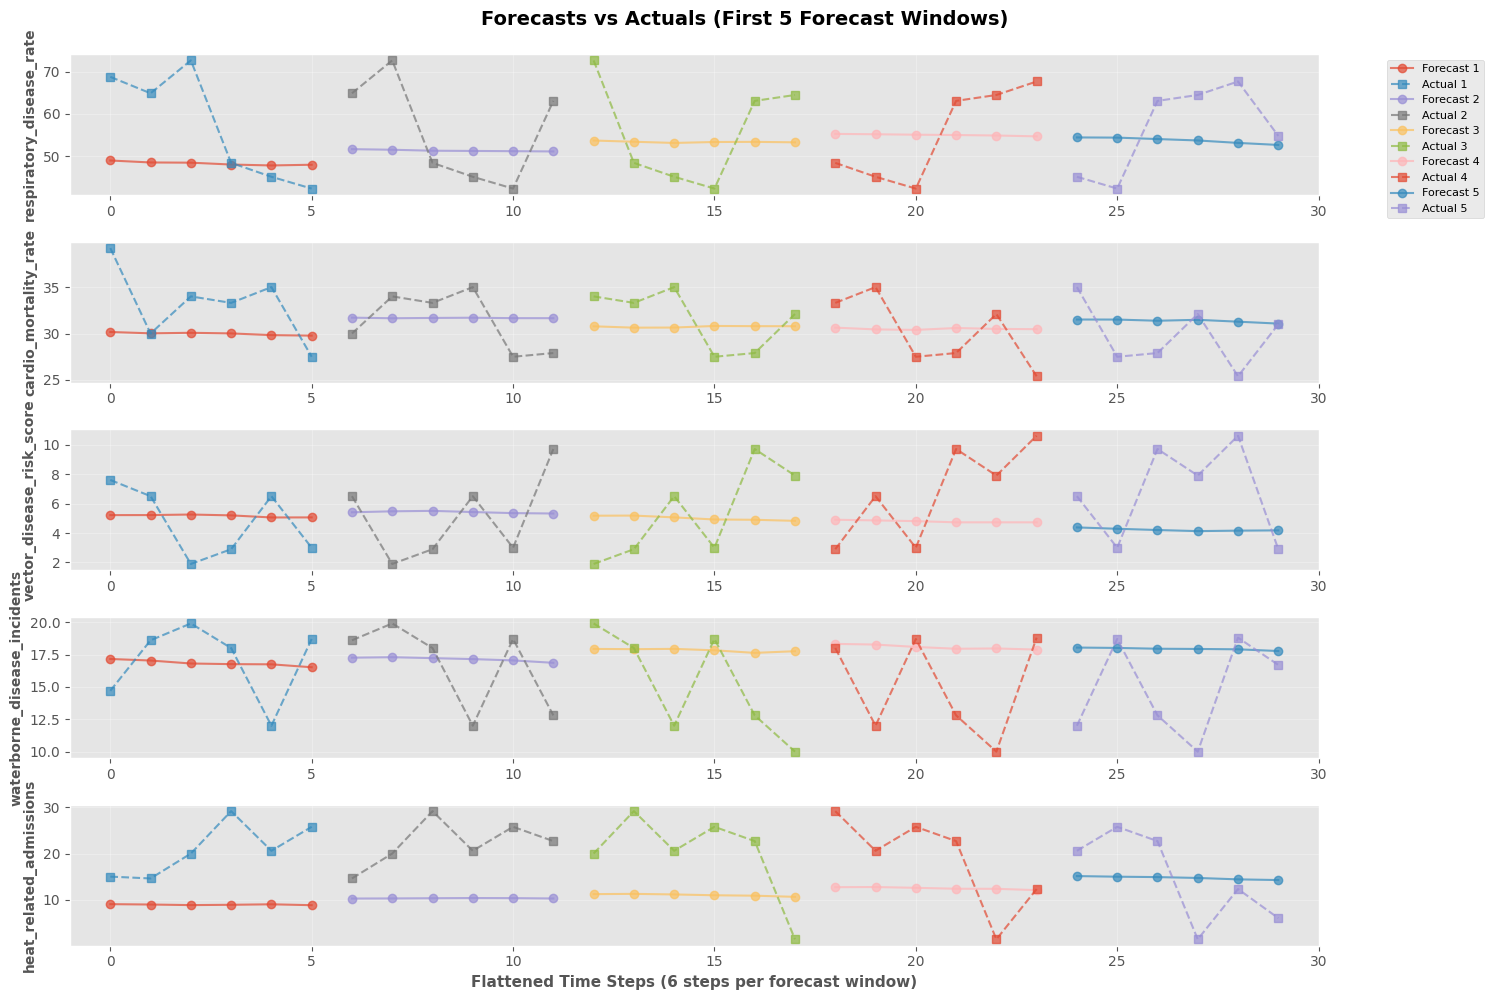

In [77]:
def visualize_forecasts_2d(preds_flat, targets_flat, num_samples=5, figsize=(15, 10)):
    """
    Visualize flattened 2D forecasts vs actuals for each target variable.
    """
    preds_flat = preds_flat.numpy()
    targets_flat = targets_flat.numpy()

    num_targets = len(targets)
    horizon = 6

    # Create subplots: one row per target variable
    fig, axes = plt.subplots(num_targets, 1, figsize=figsize, squeeze=False)

    for target_idx, target_name in enumerate(targets):
        ax = axes[target_idx, 0]

        # Plot multiple forecast windows
        for sample_idx in range(num_samples):
            start_idx = sample_idx * horizon
            end_idx = start_idx + horizon

            x_positions = np.arange(start_idx, end_idx)

            # Plot forecasts and actuals
            ax.plot(x_positions, preds_flat[start_idx:end_idx, target_idx],
                   marker='o', linestyle='-', alpha=0.7,
                   label=f'Forecast {sample_idx+1}' if target_idx == 0 else "")
            ax.plot(x_positions, targets_flat[start_idx:end_idx, target_idx],
                   marker='s', linestyle='--', alpha=0.7,
                   label=f'Actual {sample_idx+1}' if target_idx == 0 else "")

        # Styling
        ax.set_ylabel(target_name, fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-1, num_samples * horizon)

        # Only show legend on first subplot
        if target_idx == 0:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

    # X-label only on bottom subplot
    axes[-1, 0].set_xlabel('Flattened Time Steps (6 steps per forecast window)',
                           fontsize=11, fontweight='bold')

    plt.suptitle(f'Forecasts vs Actuals (First {num_samples} Forecast Windows)',
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

# 1. Overview: All targets, first 5 forecast windows
visualize_forecasts_2d(all_preds, all_targets, num_samples=5)

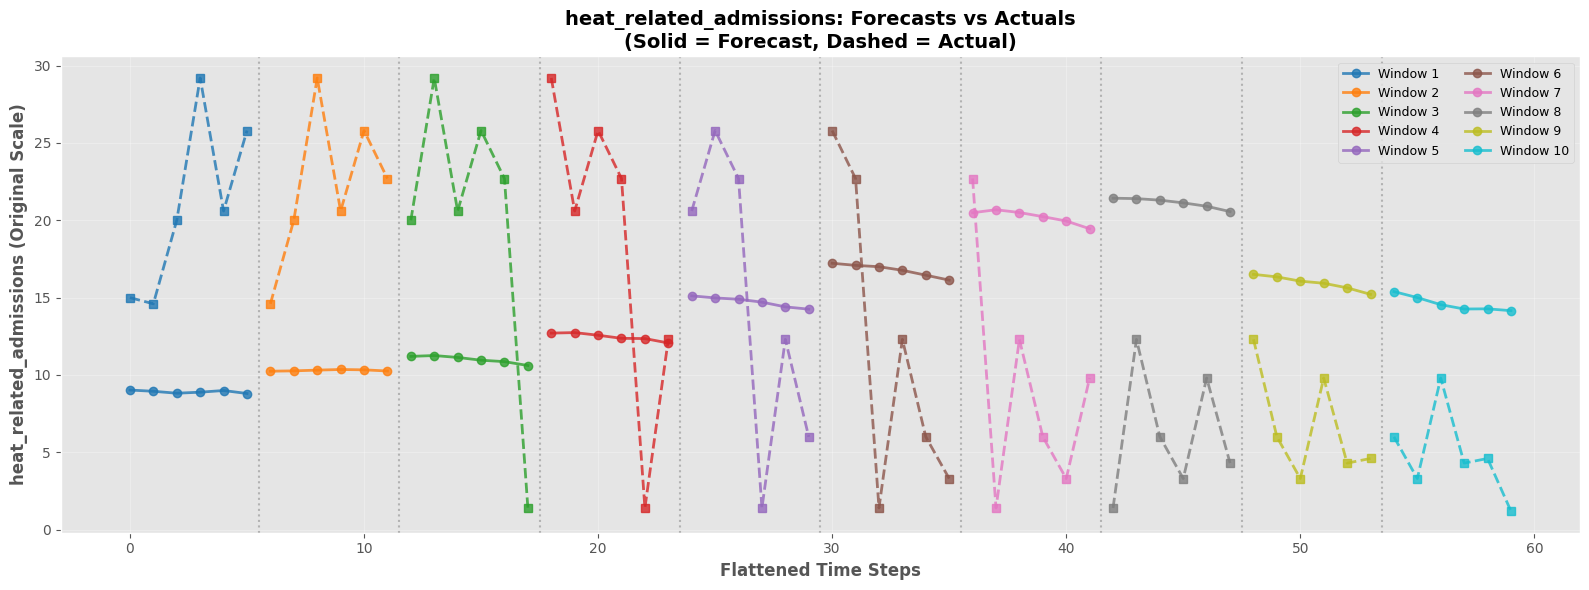

In [34]:
def visualize_single_target_detailed(preds_flat, targets_flat, target_idx, target_name, num_samples=10, figsize=(16, 6)):
    """
    Detailed visualization for a single target variable showing more samples.
    """
    preds_flat = preds_flat.numpy()
    targets_flat = targets_flat.numpy()

    horizon = 6

    fig, ax = plt.subplots(figsize=figsize)

    for sample_idx in range(num_samples):
        start_idx = sample_idx * horizon
        end_idx = start_idx + horizon

        x_positions = np.arange(start_idx, end_idx)

        # Different colors for each window
        color = plt.cm.tab10(sample_idx % 10)

        ax.plot(x_positions, preds_flat[start_idx:end_idx, target_idx],
               marker='o', linestyle='-', color=color, alpha=0.8,
               linewidth=2, markersize=6, label=f'Window {sample_idx+1}')
        ax.plot(x_positions, targets_flat[start_idx:end_idx, target_idx],
               marker='s', linestyle='--', color=color, alpha=0.8,
               linewidth=2, markersize=6)

    # Add visual separators between forecast windows
    for i in range(1, num_samples):
        ax.axvline(x=i*horizon - 0.5, color='gray', linestyle=':', alpha=0.5)

    ax.set_xlabel('Flattened Time Steps', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{target_name} (Original Scale)', fontsize=12, fontweight='bold')
    ax.set_title(f'{target_name}: Forecasts vs Actuals\n(Solid = Forecast, Dashed = Actual)',
                fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9, ncol=2)

    plt.tight_layout()
    plt.show()

# 2. Detailed view: Single target, more samples
visualize_single_target_detailed(all_preds, all_targets, target_idx=4, target_name='heat_related_admissions', num_samples=10)

### Visualize 3D Outputs

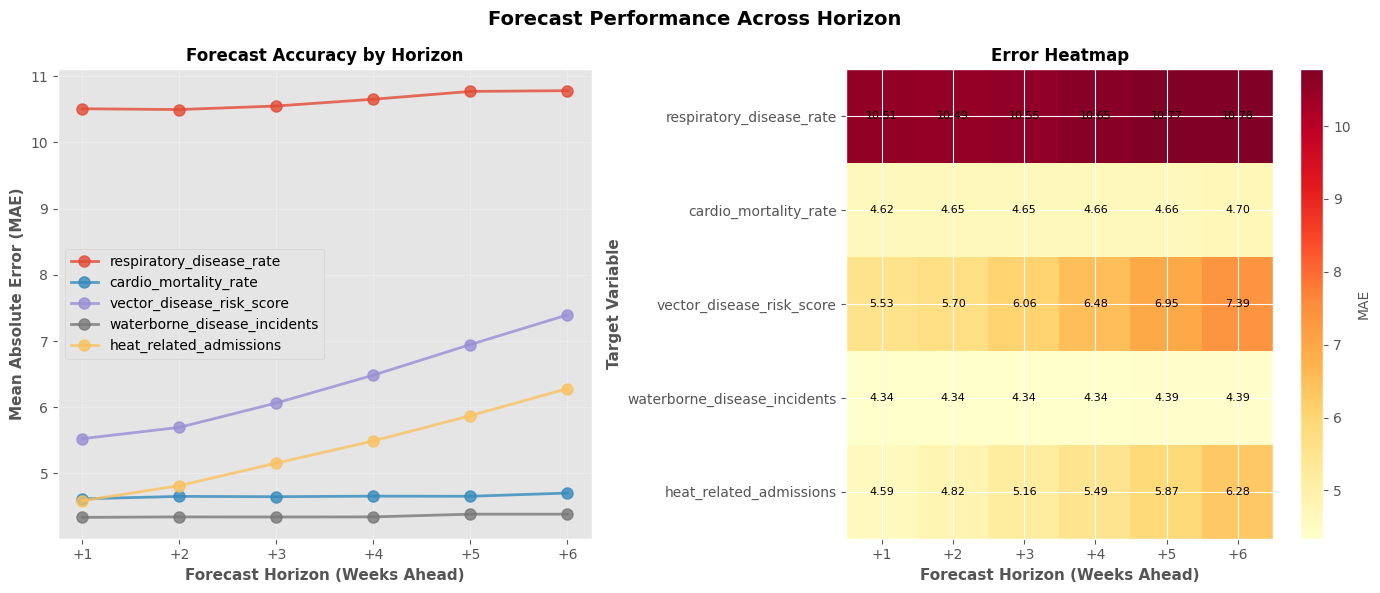

In [39]:
def visualize_horizon_performance(preds_3d, targets_3d, figsize=(14, 6)):
    """
    Show how forecast accuracy degrades over the 6-week horizon.
    """
    horizon = preds_3d.shape[1]
    num_targets = len(targets)
    weeks = np.arange(1, horizon + 1)

    # Calculate MAE per horizon step for each target
    mae_per_horizon = np.zeros((horizon, num_targets))

    for h in range(horizon):
        for t in range(num_targets):
            mae_per_horizon[h, t] = np.mean(
                np.abs(preds_3d[:, h, t].numpy() - targets_3d[:, h, t].numpy())
            )

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # Left plot: Line plot
    for t, target_name in enumerate(targets):
        ax1.plot(weeks, mae_per_horizon[:, t], marker='o', linewidth=2,
                markersize=8, label=target_name, alpha=0.8)

    ax1.set_xlabel('Forecast Horizon (Weeks Ahead)', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Mean Absolute Error (MAE)', fontsize=11, fontweight='bold')
    ax1.set_title('Forecast Accuracy by Horizon', fontsize=12, fontweight='bold')
    ax1.set_xticks(weeks)
    ax1.set_xticklabels([f'+{w}' for w in weeks])
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='best')

    # Right plot: Heatmap
    im = ax2.imshow(mae_per_horizon.T, aspect='auto', cmap='YlOrRd',
                    interpolation='nearest')
    ax2.set_xlabel('Forecast Horizon (Weeks Ahead)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Target Variable', fontsize=11, fontweight='bold')
    ax2.set_title('Error Heatmap', fontsize=12, fontweight='bold')
    ax2.set_xticks(range(horizon))
    ax2.set_xticklabels([f'+{w}' for w in weeks])
    ax2.set_yticks(range(num_targets))
    ax2.set_yticklabels(targets)

    # Add values to heatmap
    for i in range(num_targets):
        for j in range(horizon):
            text = ax2.text(j, i, f'{mae_per_horizon[j, i]:.2f}',
                          ha="center", va="center", color="black", fontsize=8)

    cbar = plt.colorbar(im, ax=ax2)
    cbar.set_label('MAE', fontsize=10)

    plt.suptitle('Forecast Performance Across Horizon', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 3. Horizon degradation analysis
visualize_horizon_performance(preds_3d, targets_3d)

## Collapse Overlapping Predictions

In [42]:
import numpy as np
import torch

def collapse_overlapping_predictions(all_preds, all_targets):
    """
    Collapse overlapping predictions from sliding window forecasting.
    :param all_preds: [num_sequences, horizon_len, num_targets]

    Returns:
        collapsed_preds: shape [horizon_len, num_targets]
        collapsed_targets: shape [horizon_len, num_targets]
        prediction_std: shape [horizon_len, num_targets] (uncertainty estimate)
    """
    num_sequences, horizon_len, num_targets = all_preds.shape

    # Create a structure to hold all predictions for each timestep
    # Total timesteps = num_sequences + horizon_len - 1
    total_timesteps = num_sequences + horizon_len - 1

    # Dictionary to store all predictions for each future timestep
    timestep_preds = {i: [] for i in range(total_timesteps)}
    timestep_targets = {i: [] for i in range(total_timesteps)}

    # Collect predictions for each timestep
    for seq_idx in range(num_sequences):
        for h in range(horizon_len):
            future_timestep = seq_idx + h
            timestep_preds[future_timestep].append(all_preds[seq_idx, h, :])
            timestep_targets[future_timestep].append(all_targets[seq_idx, h, :])

    # Get predictions for the LAST horizon_len timesteps (what you want)
    final_preds = []
    final_targets = []
    final_std = []

    for t in range(total_timesteps - horizon_len, total_timesteps):
        preds_at_t = torch.stack(timestep_preds[t])
        targets_at_t = torch.stack(timestep_targets[t])

        final_preds.append(preds_at_t.mean(dim=0))
        final_targets.append(targets_at_t.mean(dim=0))

        # Standard deviation across overlapping predictions (uncertainty!)
        final_std.append(preds_at_t.std(dim=0))

    collapsed_preds = torch.stack(final_preds)
    collapsed_targets = torch.stack(final_targets)
    prediction_std = torch.stack(final_std)

    return collapsed_preds, collapsed_targets, prediction_std

In [45]:
# Example usage with your data
# all_preds shape: [1900, 6, 5]  (1900 sequences, horizon_len=6, 5 targets)
# all_targets shape: [1900, 6, 5]

collapsed_preds, collapsed_targets, uncertainty = collapse_overlapping_predictions(preds_3d, targets_3d)

print(f"Collapsed predictions shape: {collapsed_preds.shape}")

# Build confidence intervals
z_score = 1.96  # 95% confidence
lower_bound = collapsed_preds - z_score * uncertainty
upper_bound = collapsed_preds + z_score * uncertainty

lower_bound.shape, upper_bound.shape

Collapsed predictions shape: torch.Size([6, 5])


/tmp/ipython-input-3927568205.py:44: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  final_std.append(preds_at_t.std(dim=0))


(torch.Size([6, 5]), torch.Size([6, 5]))

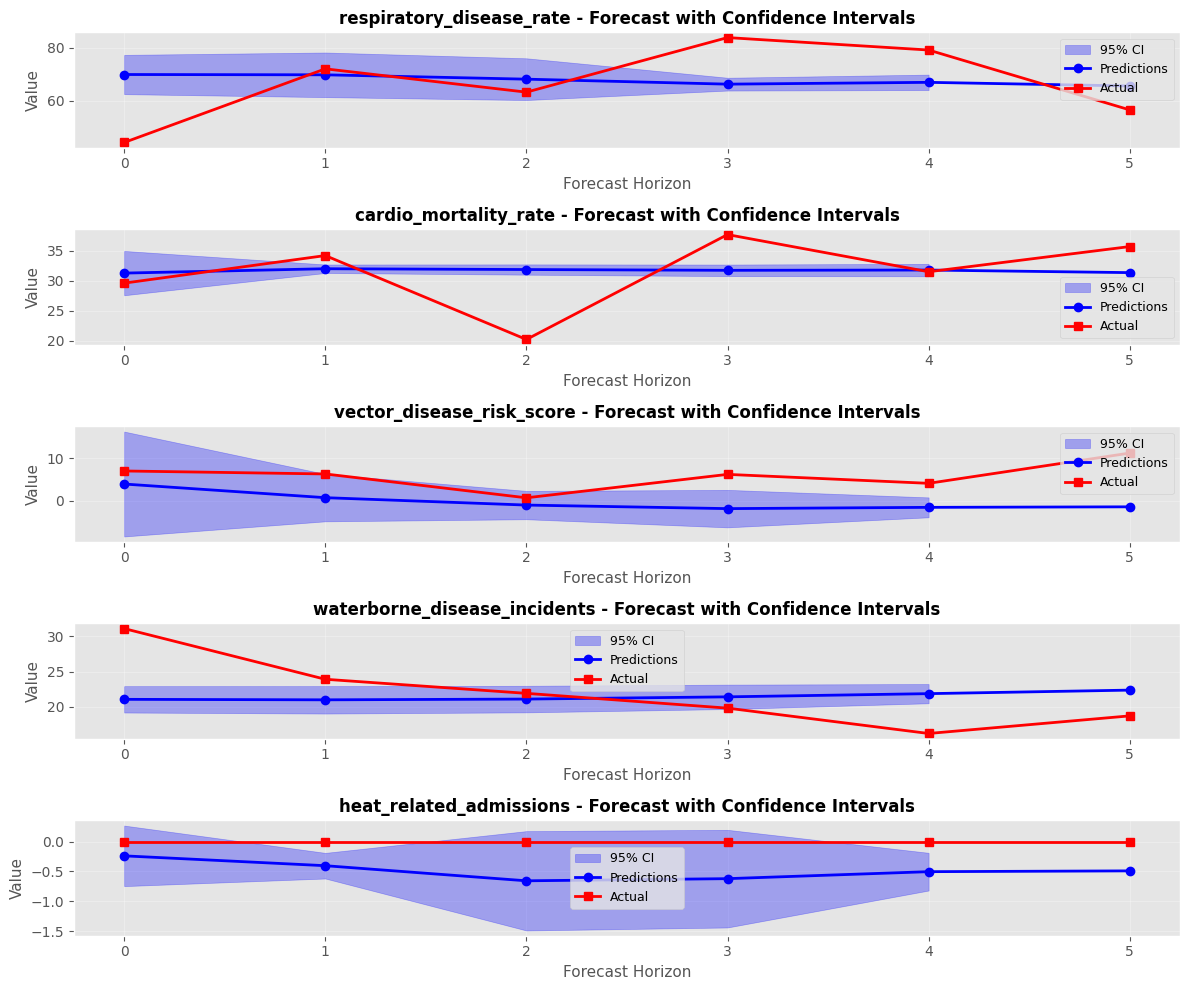

In [48]:
def plot_forecast_with_intervals_multivariate(collapsed_preds, collapsed_targets, lower_bound, upper_bound):
    """
    Visualize predictions for multiple target variables.
    """
    # Convert to numpy if torch tensors
    if isinstance(collapsed_preds, torch.Tensor):
        collapsed_preds = collapsed_preds.cpu().numpy()
        collapsed_targets = collapsed_targets.cpu().numpy()
        lower_bound = lower_bound.cpu().numpy()
        upper_bound = upper_bound.cpu().numpy()

    horizon_len, num_targets = collapsed_preds.shape
    timesteps = np.arange(horizon_len)

    # Create subplots for each target
    fig, axes = plt.subplots(num_targets, 1, figsize=(12, 2*num_targets))

    if num_targets == 1:
        axes = [axes]  # Make it iterable

    for i, ax in enumerate(axes):
        # Plot confidence interval
        ax.fill_between(timesteps, lower_bound[:, i], upper_bound[:, i], alpha=0.3, color='blue', label='95% CI')

        # Plot predictions and actuals
        ax.plot(timesteps, collapsed_preds[:, i], 'o-', color='blue', linewidth=2, markersize=6, label='Predictions')
        ax.plot(timesteps, collapsed_targets[:, i], 's-', color='red', linewidth=2, markersize=6, label='Actual')

        # Formatting
        ax.set_xlabel('Forecast Horizon', fontsize=11)
        ax.set_ylabel('Value', fontsize=11)

        target_name = targets[i] if targets else f'Target {i+1}'
        ax.set_title(f'{target_name} - Forecast with Confidence Intervals', fontsize=12, fontweight='bold')
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Usage for multivariate
plot_forecast_with_intervals_multivariate(collapsed_preds, collapsed_targets, lower_bound, upper_bound)

## Calculate metrics per target.

In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    nrmse = rmse / (y_true.max() - y_true.min() + 1e-8)
    return rmse, mae, r2, nrmse

def calculate_metrics(y_true, y_pred, save: bool = False):
    results = {}
    for i, target in enumerate(targets):
        rmse, mae, r2, nrmse = regression_metrics(y_true[:, i], y_pred[:, i])

        results[target] = {"RMSE": rmse, "MAE": mae, "R2": r2, "NRMSE_%": nrmse * 100}

    results_df = pd.DataFrame(results)
    macro_rmse = np.mean([results[t]["RMSE"] for t in targets])

    if save:
        results_df.to_csv("results.csv")

    return results_df, macro_rmse

results, overall_macro_rmse = calculate_metrics(collapsed_targets.numpy(), collapsed_preds.numpy())

In [79]:
print(f"Overall Macro RMSE: {overall_macro_rmse}")
results

Overall Macro RMSE: 6.549562241777954


,respiratory_disease_rate,cardio_mortality_rate,vector_disease_risk_score,waterborne_disease_incidents,heat_related_admissions
RMSE,14.299145,5.749224,7.058442,5.134558,5.064421e-01
MAE,11.936810,4.355821,6.105806,4.117455,4.870137e-01
R2,-0.118854,-0.018766,-3.996455,-0.165045,0.000000e+00
NRMSE_%,36.108951,32.852709,67.223253,34.460122,5.064421e+09
